In [1]:
from src.utils.DataFolder import DataFolder
from src.ThetaSignal import ThetaSignal

import emd
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
n_seconds_filter    = args.pop("n_seconds_filter")
n_seconds_theta     = args.pop("n_seconds_theta")
threshold_kwargs    = args.pop("threshold_kwargs")
skip_threshold      = args.pop("skip_threshold")

### Load the dataset

In [3]:
remFolder = DataFolder(data_path)
print(remFolder)

DataFolder in '/home/miranjo/phasic_tonic/data/processed', contains 102 files.


# Analysis

## Sample

Phasic periods in the bandpass signal: 47
Tonic periods in the bandpass signal: 865


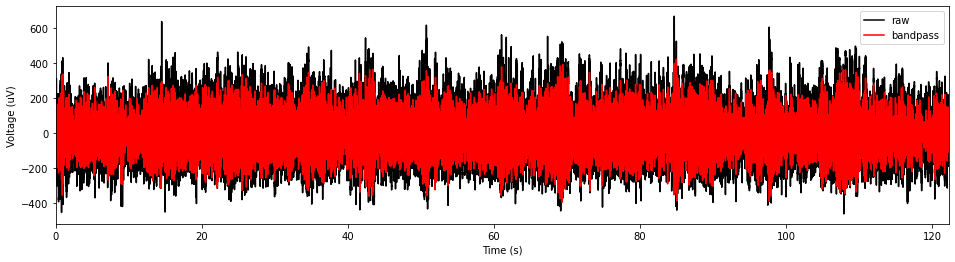

In [5]:
remData = remFolder[3]
arrays = remData["data"]
metadata = remData["metadata"]

sig = ThetaSignal(arrays[0], fs)
sig.filter('bandpass', f_theta, n_seconds_theta)
sig.segment_cycles(f_range=f_theta, skip_threshold=skip_threshold, threshold_kwargs=threshold_kwargs)
sig.plot()

In [6]:
sig.summary()

Sampling rate: 2500 Hz
Duration: 122.20 seconds
Max value: 665.82 uV
Min value: -461.92 uV
Mean value: -0.00 uV
Standard Deviation: 159.80 uV
Signal Range: 1127.73 uV
Number of Data Points: 305495


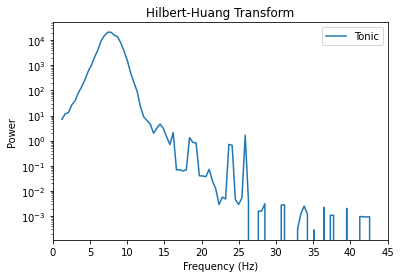

In [142]:
# Compute frequency statistics
n_bins = 100
spectrum_tot = np.zeros((len(sig.tonic), n_bins))
freq_edges, freq_centres = emd.spectra.define_hist_bins(1, 45, n_bins, 'linear')

for i, tonic in enumerate(sig.get_tonic()):
    IP, IF, IA = emd.spectra.frequency_transform((tonic-tonic.mean())/np.std(tonic), sig.sampling_rate, 'hilbert', smooth_phase=3)

    f, spectrum = emd.spectra.hilberthuang(IF, IA, freq_edges)
    spectrum_tot[i, :] = spectrum

spectrum_tot = np.mean(spectrum_tot, axis=0)
plt.plot(freq_centres, spectrum_tot)
plt.xticks(np.arange(10)*5)

plt.yscale('log')

plt.xlim(0, 45)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.title('Hilbert-Huang Transform')
plt.legend(['Tonic'])

In [128]:
spectrum.mean()

216.40646659088145

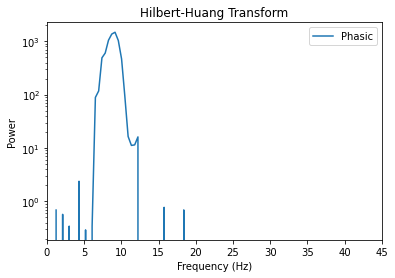

In [141]:
# Compute frequency statistics
n_bins = 100
spectrum_tot = np.zeros((len(sig.phasic), n_bins))
freq_edges, freq_centres = emd.spectra.define_hist_bins(1, 45, n_bins, 'linear')

for i, phasic in enumerate(sig.get_phasic()):
    IP, IF, IA = emd.spectra.frequency_transform((phasic-phasic.mean())/np.std(phasic), sig.sampling_rate, 'hilbert', smooth_phase=3)
    f, spectrum = emd.spectra.hilberthuang(IF, IA, freq_edges)
    spectrum_tot[i, :] = spectrum

spectrum_tot = np.mean(spectrum_tot, axis=0)
plt.plot(freq_centres, spectrum_tot)
plt.xticks(np.arange(10)*5)

plt.yscale('log')

plt.xlim(0, 45)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.title('Hilbert-Huang Transform')
plt.legend(['Phasic'])

In [130]:
spectrum.mean()

38.74666666589665

In [ ]:
# We round the values to 3dp for easier visualisation
print('Bin Edges:   {0}'.format(np.round(freq_edges, 3)))
print('Bin Centres: {0}'.format(np.round(freq_centres, 3)))

In [ ]:
10.0**np.linspace(np.log10(4), np.log(12), 20)

In [ ]:
np.linspace(start=np.log10(4), stop=np.log10(12), num=20)

## Dataset

In [66]:
def normalize(ndarray):
    return (ndarray - ndarray.mean())/np.std(ndarray)

In [151]:
n_bins = 300
spectrum_phasic = []
spectrum_tonic = []

freq_edges, freq_centres = emd.spectra.define_hist_bins(1, 45, n_bins, 'linear')

for sample in remFolder:
    lfpREMs = sample["data"]
    
    for lfpREM in lfpREMs:
        theta = ThetaSignal(lfpREM, fs)
        if(theta.duration < n_seconds_theta): 
            break    #Skip when the duration is less than 0.75s

        theta.filter('bandpass', f_theta, n_seconds_theta)
        theta.segment_cycles(f_range=f_theta, skip_threshold=skip_threshold, threshold_kwargs=threshold_kwargs)

        theta_tonic = np.zeros((len(theta.tonic), n_bins))
        theta_phasic = np.zeros((len(theta.phasic), n_bins))

        for i, tonic in enumerate(theta.get_tonic()):
            IP, IF, IA = emd.spectra.frequency_transform(tonic, sig.sampling_rate, 'hilbert', smooth_phase=3)
            f, spectrum = emd.spectra.hilberthuang(IF, IA, freq_edges)
            theta_tonic[i, :] = spectrum/len(tonic)
            
        for i, phasic in enumerate(theta.get_phasic()):
            IP, IF, IA = emd.spectra.frequency_transform(phasic, sig.sampling_rate, 'hilbert', smooth_phase=3)
            f, spectrum = emd.spectra.hilberthuang(IF, IA, freq_edges)
            theta_phasic[i, :] = spectrum/len(phasic)
        
        spectrum_tonic.append(theta_tonic)
        spectrum_phasic.append(theta_phasic)

spectrum_phasic = np.vstack(spectrum_phasic)
spectrum_tonic = np.vstack(spectrum_tonic)

Phasic periods in the bandpass signal: 9
Tonic periods in the bandpass signal: 656
Phasic periods in the bandpass signal: 11
Tonic periods in the bandpass signal: 836
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 1153
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 319
Phasic periods in the bandpass signal: 9
Tonic periods in the bandpass signal: 812
Phasic periods in the bandpass signal: 10
Tonic periods in the bandpass signal: 810
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 987
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 284
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 1219
Phasic periods in the bandpass signal: 9
Tonic periods in the bandpass signal: 1205
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 154
Phasic periods in the bandpass signal: 0
Tonic periods in the bandpass signal: 110

In [152]:
phasic_spectrum_mean = np.mean(spectrum_phasic, axis=0)
tonic_spectrum_mean = np.mean(spectrum_tonic, axis=0)

phasic_spectrum_std = np.std(spectrum_phasic, axis=0)
tonic_spectrum_std = np.std(spectrum_tonic, axis=0)

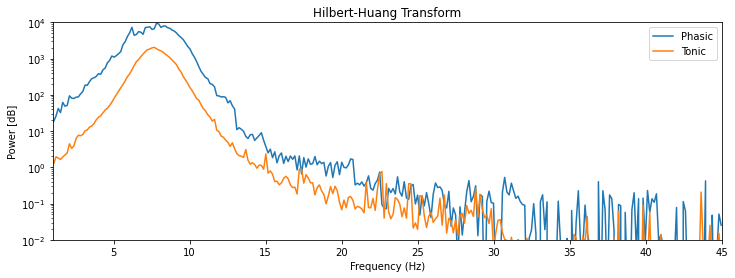

In [157]:
plt.figure(figsize=(12,4))

plt.plot(freq_centres, phasic_spectrum_mean)
plt.plot(freq_centres, tonic_spectrum_mean)

#plt.fill_between(freq_centres, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq_centres, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xticks(np.arange(10)*5)

plt.xlim(1, 45)
plt.ylim(10**-2, 10**4)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power [dB]')

plt.yscale('log')

plt.title('Hilbert-Huang Transform')
plt.legend(['Phasic', 'Tonic'])

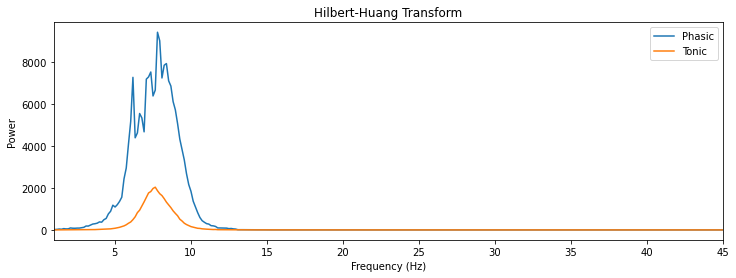

In [155]:
plt.figure(figsize=(12,4))

plt.plot(freq_centres, phasic_spectrum_mean)
plt.plot(freq_centres, tonic_spectrum_mean)

#plt.fill_between(freq_centres, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 color='alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq_centres, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xticks(np.arange(10)*5)

plt.xlim(1, 45)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.yscale('linear')

plt.title('Hilbert-Huang Transform')
plt.legend(['Phasic', 'Tonic'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7f0e2e194700>,
 'caps': [<matplotlib.lines.Line2D at 0x7f0e2e194ca0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f0e2e194430>,
 'medians': [<matplotlib.lines.Line2D at 0x7f0e2e195240>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f0e2e195510>,
 'means': []}

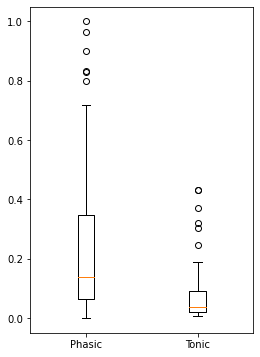

In [163]:
plt.figure(figsize=(4,6))
plt.boxplot([phasic_spectrum_mean[110:196]/phasic_spectrum_mean[110:196].max(), 
             tonic_spectrum_mean[110:196]/phasic_spectrum_mean[110:196].max()],
            labels=["Phasic", "Tonic"])

{'whiskers': [<matplotlib.lines.Line2D at 0x7f0e2e1e3af0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f0e2e01c0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f0e2e1e3820>,
 'medians': [<matplotlib.lines.Line2D at 0x7f0e2e01c670>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f0e2e01c940>,
 'means': []}

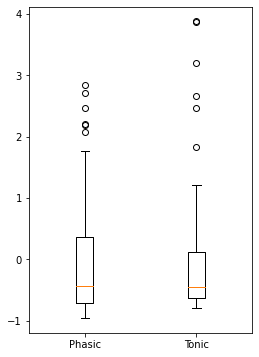

In [164]:
plt.figure(figsize=(4,6))
plt.boxplot([normalize(phasic_spectrum_mean[110:196]),
             normalize(tonic_spectrum_mean[110:196])],
            labels=["Phasic", "Tonic"])